In [1]:
import pandas as pd
import matplotlib.pyplot as plt
logs= pd.read_csv("/Users/rudrakshsharma/personal-efficiency-ledger/data/raw_logs.csv",)

In [2]:
data=logs.dropna()

In [3]:
# data

In [4]:
df = pd.DataFrame(data)

In [5]:
# df.info()

In [6]:
df.describe()

,sleep_hours,gaming,watching_YT,work_flows,workout_intensity,focus_rating
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,7.150000,1.566667,1.266667,3.200000,4.366667,6.383333
std,1.075992,1.165106,0.691492,1.827001,3.428917,2.078972
min,5.000000,0.000000,0.500000,0.000000,0.000000,2.500000
25%,6.500000,0.500000,0.625000,2.000000,0.000000,4.625000
50%,7.250000,1.250000,1.000000,3.500000,5.500000,6.750000
75%,8.000000,2.375000,1.500000,5.000000,7.000000,8.000000
max,9.000000,4.000000,3.000000,6.000000,9.000000,9.500000


In [7]:
# df[["sleep_hours","focus_rating"]]

In [8]:
sleep_focus_relation=df["sleep_hours"].corr(df["focus_rating"])
print(sleep_focus_relation)

0.16995065975256582


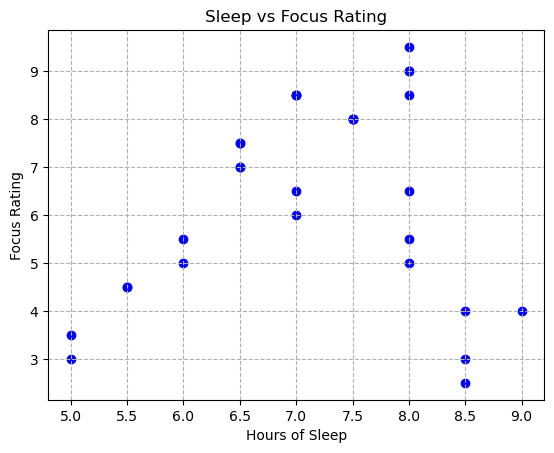

In [9]:
plt.scatter(df["sleep_hours"],df["focus_rating"],color="blue")

plt.title("Sleep vs Focus Rating")
plt.ylabel("Focus Rating")
plt.xlabel("Hours of Sleep")

plt.grid(True,linestyle="--")
plt.show()

In [10]:
good_sleep_focus=df[df["sleep_hours"]>=8.0]["focus_rating"].mean()
print(good_sleep_focus)

6.045454545454546


In [11]:
bad_sleep_focus=df[df["sleep_hours"]<8.0]["focus_rating"].mean()
print(bad_sleep_focus)

6.578947368421052


In [12]:
# relation between gaming a day before vs focus ratings

In [13]:
df["gaming_yesterday"]=df["gaming"].shift(1)

# df[["gaming_yesterday","focus_rating"]]

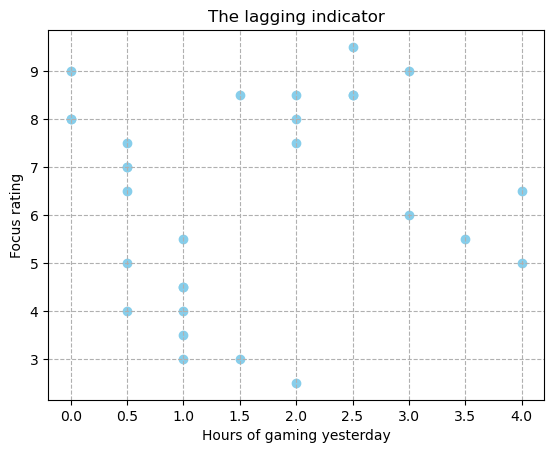

In [14]:
plt.scatter(df["gaming_yesterday"],df["focus_rating"],color="skyblue")

plt.title("The lagging indicator")
plt.xlabel("Hours of gaming yesterday")
plt.ylabel("Focus rating")

plt.grid(True,linestyle=("--"))
plt.show()

In [15]:
gaming_hangover=df["gaming_yesterday"].corr(df["focus_rating"])
print(gaming_hangover)

0.0794767857212322


In [16]:
#for watching youtube before sleeping

In [17]:
df["watching_yt_before_sleep"]=df["watching_YT"].shift(1)

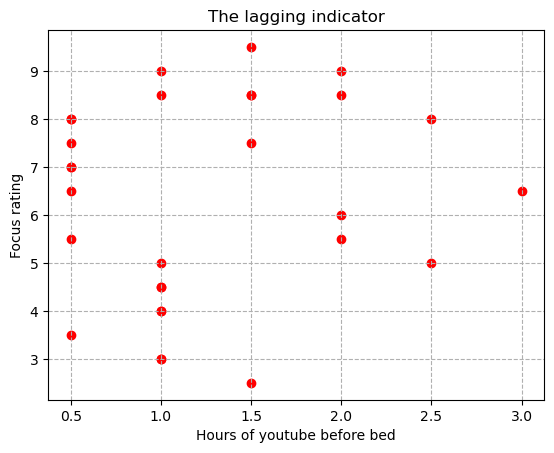

In [18]:
plt.scatter(df["watching_yt_before_sleep"],df["focus_rating"],color="red")

plt.title("The lagging indicator")
plt.xlabel("Hours of youtube before bed")
plt.ylabel("Focus rating")

plt.grid(True,linestyle=("--"))
plt.show()

In [19]:
YT_hangover=df["watching_yt_before_sleep"].corr(df["focus_rating"])
print(YT_hangover)

0.14076562566900774


In [20]:
#pushing myself a day before does ir effect my procuctivity 

In [21]:
df["yesterday_flow"]=df["work_flows"].shift(1)

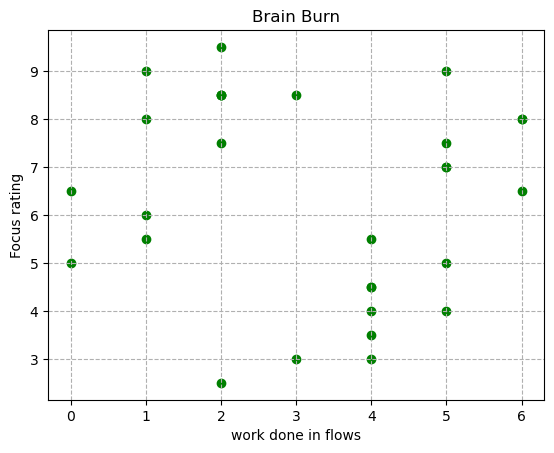

In [22]:
plt.scatter(df["yesterday_flow"],df["focus_rating"],color="green")

plt.title("Brain Burn")
plt.xlabel("work done in flows")
plt.ylabel("Focus rating")

plt.grid(True,linestyle=("--"))
plt.show()

In [23]:
flow_hangover=df["yesterday_flow"].corr(df["focus_rating"])
print(flow_hangover)

-0.0859564248282916


In [24]:
print(f"Calculated Score: {flow_hangover}")

if flow_hangover >= 0.6:
    print("Insight: Strong Positive Relation. Working more a day before is a massive multiplier for your success.")
elif flow_hangover >= 0.3:
    print("Insight: Weak Positive. This helps a little bit, but it isn't the main driver.")
elif flow_hangover > -0.3 and flow_hangover< 0.3:
    print("Insight: Statistical Noise. This habit has absolutely no impact on your focus.")
elif flow_hangover <= -0.3 and flow_hangover > -0.6:
    print("Insight: Weak Negative. This is starting to drag you down.")
elif flow_hangover <= -0.6:
    print("Insight: Strong Negative. RED ALERT. This habit is actively destroying your routine.")


print(f"Calculated Score: {YT_hangover}")

if YT_hangover >= 0.6:
    print("Insight: Strong Positive Relation. This habit is a massive multiplier for your success.")
elif YT_hangover >= 0.3:
    print("Insight: Weak Positive. This helps a little bit, but it isn't the main driver.")
elif YT_hangover > -0.3 and YT_hangover< 0.3:
    print("Insight: Statistical Noise. This habit has absolutely no impact on your focus.")
elif YT_hangover <= -0.3 and YT_hangover > -0.6:
    print("Insight: Weak Negative. This is starting to drag you down.")
elif YT_hangover <= -0.6:
    print("Insight: Strong Negative. RED ALERT. This habit is actively destroying your routine.")


print(f"Calculated Score: {gaming_hangover}")

if gaming_hangover >= 0.6:
    print("Insight: Strong Positive Relation. This habit is a massive multiplier for your success.")
elif gaming_hangover >= 0.3:
    print("Insight: Weak Positive. This helps a little bit, but it isn't the main driver.")
elif gaming_hangover > -0.3 and gaming_hangover< 0.3:
    print("Insight: Statistical Noise. This habit has absolutely no impact on your focus.")
elif gaming_hangover <= -0.3 and gaming_hangover > -0.6:
    print("Insight: Weak Negative. This is starting to drag you down.")
elif gaming_hangover <= -0.6:
    print("Insight: Strong Negative. RED ALERT. This habit is actively destroying your routine.")
    
print(f"Calculated Score: {sleep_focus_relation}")

if sleep_focus_relation >= 0.6:
    print("Insight: Strong Positive Relation. This habit is a massive multiplier for your success.")
elif sleep_focus_relation >= 0.3:
    print("Insight: Weak Positive. This helps a little bit, but it isn't the main driver.")
elif sleep_focus_relation > -0.3 and sleep_focus_relation< 0.3:
    print("Insight: Statistical Noise. This habit has absolutely no impact on your focus.")
elif sleep_focus_relation <= -0.3 and sleep_focus_relation> -0.6:
    print("Insight: Weak Negative. This is starting to drag you down.")
elif sleep_focus_relation <= -0.6:
    print("Insight: Strong Negative. RED ALERT. This habit is actively destroying your routine.")

Calculated Score: -0.0859564248282916
Insight: Statistical Noise. This habit has absolutely no impact on your focus.
Calculated Score: 0.14076562566900774
Insight: Statistical Noise. This habit has absolutely no impact on your focus.
Calculated Score: 0.0794767857212322
Insight: Statistical Noise. This habit has absolutely no impact on your focus.
Calculated Score: 0.16995065975256582
Insight: Statistical Noise. This habit has absolutely no impact on your focus.
